# RogueShield Training Notebook (UNSW-NB15)

This notebook trains the **intrusion detection part** of RogueShield on the **UNSW-NB15** dataset.

It is built for your local Windows path:

`C:\Users\anike\Downloads\Attack datasets`

It does these steps:
1. Load train/test CSVs
2. Clean and inspect the data
3. Encode categorical features
4. Scale numeric features
5. Train a TensorFlow multiclass classifier
6. Evaluate with accuracy, confusion matrix, and classification report
7. Save the trained model and preprocessing objects
8. Generate optional SHAP explainability outputs

> Important: this notebook trains the **core multiclass intrusion detection model** directly from the data you uploaded.  
> The **forecasting modules** in RogueShield (LSTM/GRU for attack category forecasting and time-to-next-attack regression) need a reliable temporal sequence. The standard UNSW-NB15 train/test CSVs are mainly for classification, so forecasting from them is **possible only as an approximation**, not as a strong ground-truth time-series pipeline.


## What RogueShield is doing

### 1) Intrusion detection model
This is the main model. It looks at a network flow record and predicts its attack category such as:
- Normal
- DoS
- Exploits
- Fuzzers
- Reconnaissance
- Generic
- Analysis
- Backdoor
- Shellcode
- Worms

### 2) Explainability
SHAP is used to explain why the model predicted a class. That helps you answer:
- Which features pushed the prediction toward DoS?
- Which features made a sample look Normal?
- Which features matter most globally?

### 3) MITRE ATT&CK mapping
This is not a native property of the dataset. It is a **rule-based interpretation layer** you add after prediction/explanation.  
That means it is useful for demonstration and analyst workflow, but it is not the same as a ground-truth MITRE-labeled dataset.

### 4) Forecasting modules
Your project description mentions:
- **LSTM** for future attack category forecasting
- **GRU** for time-to-next-attack regression

Those are sequence models. They make sense when you have:
- timestamps
- event order
- regular windows or grouped counts over time

The uploaded UNSW-NB15 train/test files do **not** provide a clean live SOC-style time stream, so the best-supported model here is the intrusion classifier.


In [1]:
# If needed, install packages here.
# Uncomment only if your environment is missing something.

# !pip install pandas numpy scikit-learn matplotlib seaborn tensorflow shap joblib

In [2]:
import sys
print(sys.executable)

c:\Users\anike\AppData\Local\Programs\Python\Python311\python.exe


In [3]:
import sys
!{sys.executable} -m pip install tensorflow scikit-learn pandas numpy matplotlib joblib shap ipykernel notebook

     --------------------------------------- 12.6/12.6 MB 23.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys
!{sys.executable} -m pip show tensorflow

Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\Users\anike\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, termcolor, typing_extensions, wrapt
Required-by: 


In [5]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [6]:
import pandas as pd

train_df = pd.read_csv(r"C:\Users\anike\Downloads\Attack datasets\UNSW_NB15_training-set.csv")
test_df = pd.read_csv(r"C:\Users\anike\Downloads\Attack datasets\UNSW_NB15_testing-set.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())

Train shape: (82332, 45)
Test shape: (175341, 45)
   id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0   1  0.000011   udp       -   INT      2      0     496       0   
1   2  0.000008   udp       -   INT      2      0    1762       0   
2   3  0.000005   udp       -   INT      2      0    1068       0   
3   4  0.000006   udp       -   INT      2      0     900       0   
4   5  0.000010   udp       -   INT      2      0    2126       0   

          rate  ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  \
0   90909.0902  ...                 1               2             0   
1  125000.0003  ...                 1               2             0   
2  200000.0051  ...                 1               3             0   
3  166666.6608  ...                 1               3             0   
4  100000.0025  ...                 1               3             0   

   ct_ftp_cmd  ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  \
0           0                 0 

In [7]:
from pathlib import Path

DATA_DIR = Path(r"C:\Users\anike\Downloads\Attack datasets")
TRAIN_PATH = DATA_DIR / "UNSW_NB15_training-set.csv"
TEST_PATH = DATA_DIR / "UNSW_NB15_testing-set.csv"

print(TRAIN_PATH.exists(), TRAIN_PATH)
print(TEST_PATH.exists(), TEST_PATH)

True C:\Users\anike\Downloads\Attack datasets\UNSW_NB15_training-set.csv
True C:\Users\anike\Downloads\Attack datasets\UNSW_NB15_testing-set.csv


In [8]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

import joblib

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [9]:
DATA_DIR = Path(r"C:\Users\anike\Downloads\Attack datasets")

TRAIN_PATH = DATA_DIR / "UNSW_NB15_training-set.csv"
TEST_PATH = DATA_DIR / "UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.columns.tolist())

Train shape: (82332, 45)
Test shape: (175341, 45)
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [10]:
for col in ["label", "attack_cat"]:
    if col in train_df.columns:
        print(col, train_df[col].head())
        print(train_df[col].value_counts(dropna=False).head(15))
        print("-" * 50)

label 0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64
label
1    45332
0    37000
Name: count, dtype: int64
--------------------------------------------------
attack_cat 0    Normal
1    Normal
2    Normal
3    Normal
4    Normal
Name: attack_cat, dtype: str
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64
--------------------------------------------------


In [11]:
from pathlib import Path

DATA_DIR = Path(r"C:\Users\anike\Downloads\Attack datasets")

TRAIN_PATH = DATA_DIR / "UNSW_NB15_training-set.csv"
TEST_PATH = DATA_DIR / "UNSW_NB15_testing-set.csv"
FEATURES_PATH = DATA_DIR / "NUSW-NB15_features.csv"

In [12]:
train_df.columns = [c.strip() for c in train_df.columns]
test_df.columns = [c.strip() for c in test_df.columns]

TARGET_COL = "attack_cat"

train_df[TARGET_COL] = train_df[TARGET_COL].fillna("Normal").astype(str).str.strip()
test_df[TARGET_COL] = test_df[TARGET_COL].fillna("Normal").astype(str).str.strip()

DROP_COLS = [TARGET_COL]
if "label" in train_df.columns:
    DROP_COLS.append("label")
if "id" in train_df.columns:
    DROP_COLS.append("id")

X_train_df = train_df.drop(columns=DROP_COLS, errors="ignore")
X_test_df = test_df.drop(columns=DROP_COLS, errors="ignore")

y_train_raw = train_df[TARGET_COL]
y_test_raw = test_df[TARGET_COL]

print("X_train:", X_train_df.shape)
print("X_test:", X_test_df.shape)
print("Classes:", sorted(y_train_raw.unique()))

X_train: (82332, 42)
X_test: (175341, 42)
Classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [13]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

num_classes = len(label_encoder.classes_)
print("Encoded classes:", list(label_encoder.classes_))
print("Num classes:", num_classes)

Encoded classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
Num classes: 10


In [14]:
categorical_cols = X_train_df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [c for c in X_train_df.columns if c not in categorical_cols]

print("Categorical:", categorical_cols)
print("Numeric count:", len(numeric_cols))

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

X_train = preprocessor.fit_transform(X_train_df)
X_test = preprocessor.transform(X_test_df)

print("Processed X_train shape:", X_train.shape)
print("Processed X_test shape:", X_test.shape)

Categorical: ['proto', 'service', 'state']
Numeric count: 39
Processed X_train shape: (82332, 190)
Processed X_test shape: (175341, 190)


In [15]:
y_train_cat = keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=num_classes)

In [16]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
print(class_weight_dict)

{0: 12.161299852289513, 1: 14.1221269296741, 2: 2.013499633162142, 3: 0.739597556593604, 4: 1.3581656219069613, 5: 0.4362884849769488, 6: 0.22251891891891892, 7: 2.3550343249427916, 8: 21.78095238095238, 9: 187.11818181818182}


In [17]:
input_dim = X_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        48,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,234 (360.29 KB)

 Trainable params: 91,466 (357.29 KB)

 Non-trainable params: 768 (3.00 KB)

In [18]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6222 - loss: 1.8936 - val_accuracy: 0.0419 - val_loss: 3.4384 - learning_rate: 0.0010
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6982 - loss: 1.5413 - val_accuracy: 0.0477 - val_loss: 3.8365 - learning_rate: 0.0010
Epoch 3/30
253/258 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7018 - loss: 1.4895
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7077 - loss: 1.4469 - val_accuracy: 0.0515 - val_loss: 3.6115 - learning_rate: 0.0010
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7219 - loss: 1.3685 - val_accuracy: 0.0522 - val_loss: 3.6239 - learning_rate: 5.0000e-04
Epoch 5/30
248/258 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7173 - loss: 1.3546
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7218 - loss: 1.3474 

In [19]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", acc)
print("Weighted F1:", f1)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 4s 797us/step
Accuracy: 0.6221134817298863
Weighted F1: 0.6723481074686576
                precision    recall  f1-score   support

      Analysis       0.05      0.18      0.08      2000
      Backdoor       0.00      0.00      0.00      1746
           DoS       0.31      0.59      0.41     12264
      Exploits       0.70      0.40      0.51     33393
       Fuzzers       0.48      0.31      0.37     18184
       Generic       0.99      0.98      0.99     40000
        Normal       1.00      0.73      0.84     56000
Reconnaissance       0.34      0.15      0.21     10491
     Shellcode       0.04      0.80      0.08      1133
         Worms       0.01      0.89      0.02       130

      accuracy                           0.62    175341
     macro avg       0.39      0.50      0.35    175341
  weighted avg       0.77      0.62      0.67    175341



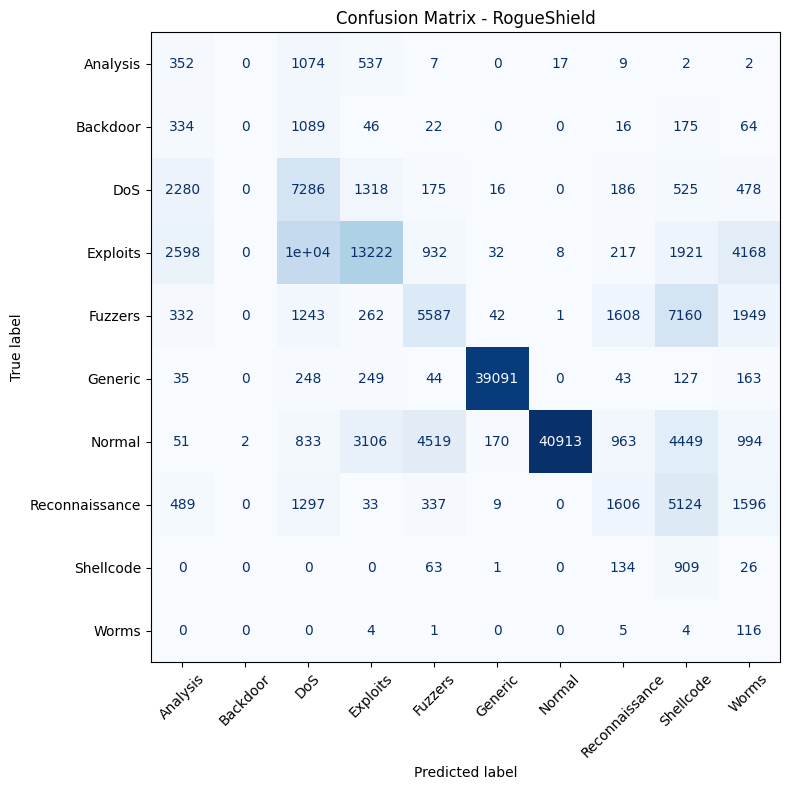

In [20]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - RogueShield")
plt.tight_layout()
plt.show()

In [21]:
SAVE_DIR = DATA_DIR / "rogueshield_outputs"
SAVE_DIR.mkdir(exist_ok=True)

model.save(SAVE_DIR / "intrusion_classifier.keras")
joblib.dump(preprocessor, SAVE_DIR / "preprocessor.joblib")
joblib.dump(label_encoder, SAVE_DIR / "label_encoder.joblib")

print("Saved to:", SAVE_DIR)

Saved to: C:\Users\anike\Downloads\Attack datasets\rogueshield_outputs


In [22]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path(r"C:\Users\anike\Downloads\Wireshark file")
print(list(DATA_DIR.iterdir()))

[WindowsPath('C:/Users/anike/Downloads/Wireshark file/live_packets.csv')]


In [23]:
from pathlib import Path

folder = Path(r"C:\Users\anike\Downloads\Wireshark file")

for f in folder.iterdir():
    print(f.name)

live_packets.csv


In [24]:
import pandas as pd

live_df = pd.read_csv(
    r"C:\Users\anike\Downloads\Wireshark file\live_packets.csv",
    encoding="latin1"
)

print(live_df.head())
print(live_df.columns.tolist())
print(live_df.shape)

   No.      Time         Source    Destination Protocol  Length  \
0    1  0.000000  172.17.34.176  40.97.188.242      TCP      55   
1    2  0.018465  40.97.188.242  172.17.34.176      TCP      66   
2    3  0.093775  172.17.34.176   172.17.34.52  TLSv1.2     164   
3    4  0.101666   172.17.34.52  172.17.34.176  TLSv1.2     164   
4    5  0.153831  172.17.34.176   172.17.34.52      TCP      54   

                                                Info  
0      64198  >  443 [ACK] Seq=1 Ack=1 Win=255 Len=1  
1  443  >  64198 [ACK] Seq=1 Ack=2 Win=255 Len=0 ...  
2                                   Application Data  
3                                   Application Data  
4  55764  >  8009 [ACK] Seq=111 Ack=111 Win=255 L...  
['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']
(651, 7)


In [25]:
print(live_df.columns.tolist())

['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']


In [26]:
pip install cicflowmeter

  Using cached cicflowmeter-0.2.0-py3-none-any.whl (16 kB)
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\anike\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\~-mpy.libs\\libscipy_openblas64_-63c857e738469261263c764a36be9436.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
